Guardado: fig34.svg y fig34.png


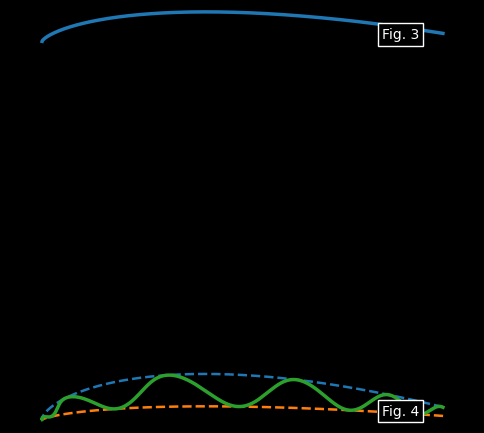

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gamma_curve(delta, gamma, lam, x_min=-2.2, x_max=2.2, n=20000):
    x = np.linspace(x_min, x_max, n)
    r = np.exp(-np.exp(x))                    # (0,1)
    theta = (delta + gamma*np.sin(lam*x)) * np.exp(x)
    z = r * np.exp(1j*theta)
    return z

def style_ax(ax):
    ax.set_aspect("equal", adjustable="box")
    ax.set_facecolor("black")
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

# --- Ajustes iniciales (tómalos como perillas)
delta = 0.18
lam   = 8.0
gam   = 0.10

# Fig. 3 (paper): normalmente usan el caso "sin oscilación" para comparar
z3 = gamma_curve(delta=delta, gamma=0.0, lam=lam)

# Fig. 4 (paper): oscilante + envolventes tipo δ±γ (en el texto hablan de h(x)=δ+γ sin(λx))
z4  = gamma_curve(delta=delta, gamma=gam, lam=lam)
zU  = gamma_curve(delta=delta+gam, gamma=0.0, lam=lam)  # envolvente superior
zL  = gamma_curve(delta=delta-gam, gamma=0.0, lam=lam)  # envolvente inferior

fig = plt.figure(figsize=(6,9), facecolor="black")
gs = fig.add_gridspec(2,1, height_ratios=[1,1], hspace=0.15)

ax1 = fig.add_subplot(gs[0,0]); style_ax(ax1)
ax2 = fig.add_subplot(gs[1,0]); style_ax(ax2)

# --- Fig. 3: trazo “chalk”
ax1.plot(z3.real, z3.imag, linewidth=2.5)
ax1.text(0.80, 0.15, "Fig. 3", transform=ax1.transAxes, color="white",
         bbox=dict(facecolor="black", edgecolor="white", boxstyle="square,pad=0.3"))

# --- Fig. 4: envolventes punteadas + curva oscilante sólida
ax2.plot(zU.real, zU.imag, linewidth=1.8, linestyle="--")
ax2.plot(zL.real, zL.imag, linewidth=1.8, linestyle="--")
ax2.plot(z4.real, z4.imag, linewidth=2.5)

ax2.text(0.80, 0.15, "Fig. 4", transform=ax2.transAxes, color="white",
         bbox=dict(facecolor="black", edgecolor="white", boxstyle="square,pad=0.3"))

# recorte automático “bonito”
def autoset(ax, z, pad=0.08):
    xmin, xmax = z.real.min(), z.real.max()
    ymin, ymax = z.imag.min(), z.imag.max()
    dx, dy = xmax-xmin, ymax-ymin
    ax.set_xlim(xmin - pad*dx, xmax + pad*dx)
    ax.set_ylim(ymin - pad*dy, ymax + pad*dy)

autoset(ax1, z3)
autoset(ax2, z4)

plt.savefig("fig34.svg", format="svg", facecolor="black")
plt.savefig("fig34.png", dpi=300, facecolor="black")
print("Guardado: fig34.svg y fig34.png")
